# Tutorial 6: Transformers and Multi-Head Attention

This notebook tries to replicate the original PyTorch Lightning implementation using Keras and TensorFlow. All custom classes and logic are adapted for Keras. I realized too late that the first classes were not required to be replicated.

In [23]:
# Standard libraries
import os
import numpy as np
import random
import math
import json
from functools import partial
import matplotlib.pyplot as plt
import seaborn as sns
sns.reset_orig()
from tqdm.notebook import tqdm

In [24]:
# TensorFlow/Keras imports
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [25]:
# Set random seed for reproducibility
tf.random.set_seed(42)
np.random.seed(42)

## The Transformer architecture (Keras)

In [26]:
def scaled_dot_product(q, k, v, mask=None):
    d_k = tf.cast(tf.shape(k)[-1], tf.float32)
    attn_logits = tf.matmul(q, k, transpose_b=True) / tf.math.sqrt(d_k)
    if mask is not None:
        attn_logits += (mask * -1e9)
    attention = tf.nn.softmax(attn_logits, axis=-1)
    values = tf.matmul(attention, v)
    return values, attention

In [27]:
seq_len, d_k = 3, 2
q = np.random.rand(seq_len, d_k).astype(np.float32)
k = np.random.rand(seq_len, d_k).astype(np.float32)
v = np.random.rand(seq_len, d_k).astype(np.float32)
values, attention = scaled_dot_product(q, k, v)
print("Q\n", q)
print("K\n", k)
print("V\n", v)
print("Values\n", values)
print("Attention\n", attention)

Q
 [[0.37454012 0.9507143 ]
 [0.7319939  0.5986585 ]
 [0.15601864 0.15599452]]
K
 [[0.05808361 0.8661761 ]
 [0.601115   0.7080726 ]
 [0.02058449 0.96990985]]
V
 [[0.83244264 0.21233912]
 [0.18182497 0.1834045 ]
 [0.30424225 0.52475643]]
Values
 tf.Tensor(
[[0.43363515 0.30964315]
 [0.41962066 0.2994583 ]
 [0.43551385 0.30560187]], shape=(3, 2), dtype=float32)
Attention
 tf.Tensor(
[[0.32259393 0.33493102 0.34247506]
 [0.3064095  0.3795805  0.31401005]
 [0.32779196 0.34201267 0.33019537]], shape=(3, 3), dtype=float32)


### Multi-Head Attention (Keras)

In [28]:
def expand_mask(mask):
    assert mask.ndim >= 2, "Mask must be at least 2-dimensional with seq_length x seq_length"
    if mask.ndim == 3:
        mask = mask.unsqueeze(1)
    while mask.ndim < 4:
        mask = mask.unsqueeze(0)
    return mask

In [29]:
class MultiHeadAttention(layers.Layer):
    def __init__(self, input_dim, embed_dim, num_heads):
        super().__init__()
        assert embed_dim % num_heads == 0, "Embedding dimension must be divisible by number of heads."
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.head_dim = embed_dim // num_heads

        # Stack all weight matrices 1...h together for efficiency
        # Note that in many implementations you see "bias=False" which is optional
        self.qkv_proj = layers.Dense(3 * embed_dim, use_bias=True,
                                     kernel_initializer=tf.keras.initializers.GlorotUniform(),
                                     bias_initializer='zeros')
        self.o_proj = layers.Dense(input_dim, use_bias=True,
                                  kernel_initializer=tf.keras.initializers.GlorotUniform(),
                                  bias_initializer='zeros')

        # self._reset_parameters()
        # this is replaced by kernel_initializer and bias_initializer

    def call(self, x, mask=None, return_attention=False):
        batch_size = tf.shape(x)[0]
        seq_length = tf.shape(x)[1]
        if mask is not None:
            mask = expand_mask(mask)
        qkv = self.qkv_proj(x)

        # Separate Q, K, V from linear output
        qkv = tf.reshape(qkv, (batch_size, seq_length, self.num_heads, 3 * self.head_dim))
        qkv = tf.transpose(qkv, perm=[0, 2, 1, 3])
        q, k, v = tf.split(qkv, 3, axis=-1)

        # Determine value outputs
        values, attention = scaled_dot_product(q, k, v, mask=mask)
        values = tf.transpose(values, perm=[0, 2, 1, 3])
        values = tf.reshape(values, (batch_size, seq_length, self.embed_dim))
        o = self.o_proj(values)

        if return_attention:
            return o, attention
        else:
            return o

### Transformer Encoder Block (Keras)

In [30]:
class EncoderBlock(layers.Layer):
    def __init__(self, input_dim, num_heads, dim_feedforward, dropout=0.0):
        """
        Inputs:
            input_dim - Dimensionality of the input
            num_heads - Number of heads to use in the attention block
            dim_feedforward - Dimensionality of the hidden layer in the MLP
            dropout - Dropout probability to use in the dropout layers
        """
        super().__init__()

        # Attention layer
        self.self_attn = MultiHeadAttention(input_dim, input_dim, num_heads)

        # Two-layer MLP
        self.linear_net = keras.Sequential([
            layers.Dense(dim_feedforward),
            layers.Dropout(dropout),
            layers.ReLU(),
            layers.Dense(input_dim),
        ])

        # Layers to apply in between the main layers
        self.norm1 = layers.LayerNormalization(epsilon=1e-6)
        self.norm2 = layers.LayerNormalization(epsilon=1e-6)
        self.dropout = layers.Dropout(dropout)

    def call(self, x, mask=None):
        # Attention part
        attn_out = self.self_attn(x, mask=mask)
        x = x + self.dropout(attn_out)
        x = self.norm1(x)

        # MLP part
        linear_out = self.linear_net(x)
        x = x + self.dropout(linear_out)
        x = self.norm2(x)

        return x

### Transformer Encoder (Keras)

In [31]:
class TransformerEncoder(layers.Layer):
    def __init__(self, num_layers, **block_args):
        super().__init__()
        self.layers = [EncoderBlock(**block_args) for _ in range(num_layers)]

    def call(self, x, mask=None):
        for l in self.layers:
            x = l(x, mask=mask)
        return x

    def get_attention_maps(self, x, mask=None):
        attention_maps = []
        for l in self.layers:
            _, attn_map = l.self_attn(x, mask=mask, return_attention=True)
            attention_maps.append(attn_map)
            x = l(x, mask=mask)
        return attention_maps

### Positional Encoding (Keras)

In [32]:
class PositionalEncoding(layers.Layer):
    def __init__(self, d_model, max_len=5000):
        """
        Inputs
            d_model - Hidden dimensionality of the input.
            max_len - Maximum length of a sequence to expect.
        """
        super().__init__()

        # Create matrix of [SeqLen, HiddenDim] representing the positional encoding for max_len inputs
        pos_encoding = np.zeros((max_len, d_model), dtype=np.float32)
        position = np.arange(max_len)[:, np.newaxis]
        div_term = np.exp(np.arange(0, d_model, 2) * (-math.log(10000.0) / d_model))
        pos_encoding[:, 0::2] = np.sin(position * div_term)
        pos_encoding[:, 1::2] = np.cos(position * div_term)
        self.pos_encoding = tf.constant(pos_encoding, dtype=tf.float32)

    def call(self, x):
        seq_len = tf.shape(x)[1]
        pos = self.pos_encoding[:seq_len, :]
        pos = tf.expand_dims(pos, axis=0)
        return x + pos

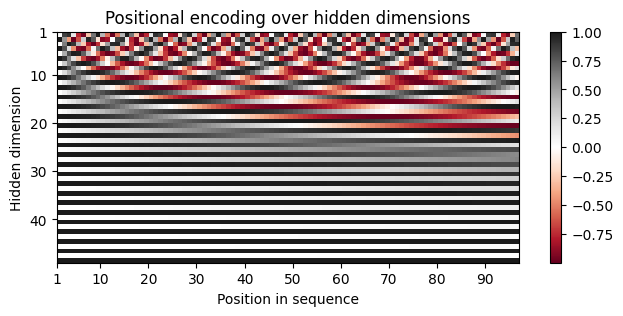

In [33]:
encod_block = PositionalEncoding(d_model=48, max_len=96)
pe = np.transpose(encod_block.pos_encoding)

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(8,3))
pos = ax.imshow(pe, cmap="RdGy", extent=(1,pe.shape[1]+1,pe.shape[0]+1,1))
fig.colorbar(pos, ax=ax)
ax.set_xlabel("Position in sequence")
ax.set_ylabel("Hidden dimension")
ax.set_title("Positional encoding over hidden dimensions")
ax.set_xticks([1]+[i*10 for i in range(1,1+pe.shape[1]//10)])
ax.set_yticks([1]+[i*10 for i in range(1,1+pe.shape[0]//10)])
plt.show()

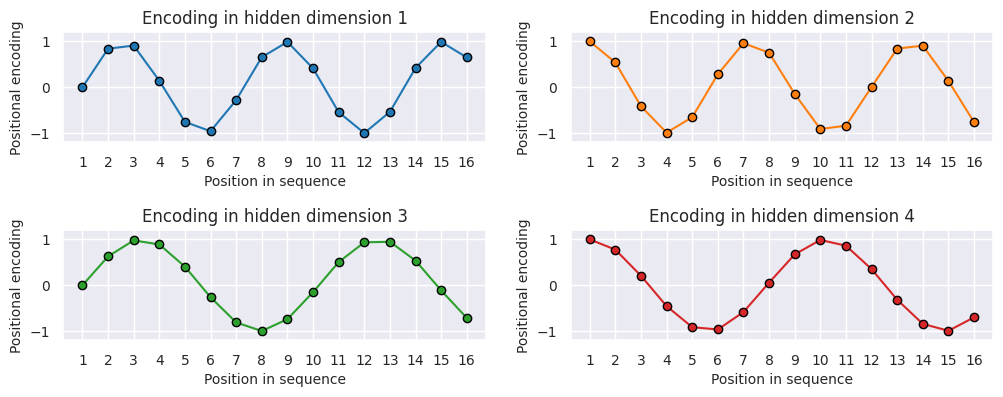

In [34]:
sns.set_theme()
fig, ax = plt.subplots(2, 2, figsize=(12,4))
ax = [a for a_list in ax for a in a_list]
for i in range(len(ax)):
    ax[i].plot(np.arange(1,17), pe[i,:16], color=f'C{i}', marker="o", markersize=6, markeredgecolor="black")
    ax[i].set_title(f"Encoding in hidden dimension {i+1}")
    ax[i].set_xlabel("Position in sequence", fontsize=10)
    ax[i].set_ylabel("Positional encoding", fontsize=10)
    ax[i].set_xticks(np.arange(1,17))
    ax[i].tick_params(axis='both', which='major', labelsize=10)
    ax[i].tick_params(axis='both', which='minor', labelsize=8)
    ax[i].set_ylim(-1.2, 1.2)
fig.subplots_adjust(hspace=0.8)
sns.reset_orig()
plt.show()

In [35]:
class CosineWarmupScheduler(tf.keras.optimizers.schedules.LearningRateSchedule):
    def __init__(self, base_lr, warmup, max_iters):
        super().__init__()
        self.base_lr = base_lr
        self.warmup = warmup
        self.max_iters = max_iters

    def __call__(self, step):
        step = tf.cast(step, tf.float32)
        lr_factor = self.get_lr_factor(step)
        return self.base_lr * lr_factor

    def get_lr_factor(self, step):
        step = float(step)
        lr_factor = 0.5 * (1 + np.cos(np.pi * step / self.max_iters))
        warmup_factor = step / self.warmup if step <= self.warmup else 1.0
        return lr_factor * warmup_factor

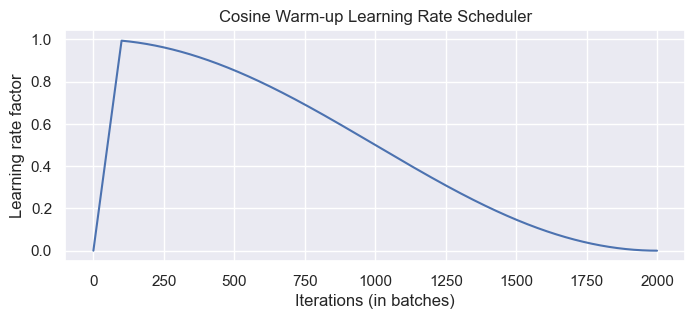

In [36]:
lr_scheduler = CosineWarmupScheduler(base_lr=1e-3, warmup=100, max_iters=2000)

# Plotting
epochs = list(range(2000))
sns.set()
plt.figure(figsize=(8,3))
plt.plot(epochs, [lr_scheduler.get_lr_factor(e) for e in epochs])
plt.ylabel("Learning rate factor")
plt.xlabel("Iterations (in batches)")
plt.title("Cosine Warm-up Learning Rate Scheduler")
plt.show()
sns.reset_orig()

In [37]:
class TransformerPredictor(tf.keras.Model):
    def __init__(self, input_dim, model_dim, num_classes, num_heads, num_layers, lr, warmup, max_iters, dropout=0.0, input_dropout=0.0):
        """
        Inputs:
            input_dim - Vocabulary size (number of token categories)
            model_dim - Hidden dimensionality to use inside the Transformer
            num_classes - Number of classes to predict per sequence element
            num_heads - Number of heads to use in the Multi-Head Attention blocks
            num_layers - Number of encoder blocks to use.
            lr - Learning rate in the optimizer
            warmup - Number of warmup steps. Usually between 50 and 500
            max_iters - Number of maximum iterations the model is trained for. This is needed for the CosineWarmup scheduler
            dropout - Dropout to apply inside the model
            input_dropout - Dropout to apply on the input features
        """
        super().__init__()

        # Embedding layer to convert token IDs to embeddings
        self.embedding = layers.Embedding(input_dim=input_dim, output_dim=model_dim)
        self.input_dropout = layers.Dropout(input_dropout)
        # Positional encoding for sequences
        self.positional_encoding = PositionalEncoding(d_model=model_dim)
        # Transformer
        self.transformer = TransformerEncoder(
            num_layers=num_layers,
            input_dim=model_dim,
            dim_feedforward=2*model_dim,
            num_heads=num_heads,
            dropout=dropout
        )
        # Output classifier per sequence element
        self.output_net = keras.Sequential([
            layers.Dense(model_dim),
            layers.LayerNormalization(epsilon=1e-6),
            layers.ReLU(),
            layers.Dropout(dropout),
            layers.Dense(num_classes)
        ])
        # Apply lr scheduler per step
        self.lr_schedule = CosineWarmupScheduler(base_lr=lr, warmup=warmup, max_iters=max_iters)
        self.optimizer = keras.optimizers.Adam(learning_rate=self.lr_schedule)

    def call(self, x, mask=None, add_positional_encoding=True):
        """
        Inputs:
            x - Input token IDs of shape [Batch, SeqLen]
            mask - Mask to apply on the attention outputs (optional)
            add_positional_encoding - If True, we add the positional encoding to the input.
                                      Might not be desired for some tasks.
        """
        x = self.embedding(x)
        x = self.input_dropout(x)
        if add_positional_encoding:
            x = self.positional_encoding(x)
        x = self.transformer(x, mask=mask)
        x = self.output_net(x)  # [batch, seq_len, num_classes] - outputs logits
        return x
    
    def get_attention_maps(self, x, mask=None, add_positional_encoding=True):
        """
        Function for extracting the attention matrices of the whole Transformer for a single batch.
        Input arguments same as the forward pass.
        """
        x = self.embedding(x)
        x = self.input_dropout(x)
        if add_positional_encoding:
            x = self.positional_encoding(x)
        attention_maps = self.transformer.get_attention_maps(x, mask=mask)
        return attention_maps

## Reverse Sequence Dataset (Keras)

In [38]:
class ReverseDataset(tf.keras.utils.Sequence):
    def __init__(self, num_categories, seq_len, size, batch_size=32):
        super().__init__()
        self.num_categories = num_categories
        self.seq_len = seq_len
        self.size = size
        self.batch_size = batch_size
        self.data = np.random.randint(num_categories, size=(size, seq_len))
        self.indices = np.arange(self.size)

    def __len__(self):
        return (self.size + self.batch_size - 1) // self.batch_size
    
    def __getitem__(self, idx):
        batch_indices = self.indices[idx*self.batch_size:(idx+1)*self.batch_size]
        batch_x = self.data[batch_indices]
        batch_y = np.flip(batch_x, axis=1)
        return batch_x, batch_y
    
    def on_epoch_end(self):
        np.random.shuffle(self.indices)

## Build the Keras Transformer Model

In [39]:
def build_transformer(seq_length=16, vocab_size=10, d_model=32, num_heads=1, ff_dim=64, num_layers=1, dropout=0.0):
    inputs = layers.Input(shape=(seq_length,))
    x = layers.Embedding(vocab_size, d_model)(inputs)
    x = PositionalEncoding(d_model, max_len=seq_length)(x)
    x = TransformerEncoder(
        num_layers,
        input_dim=d_model,
        num_heads=num_heads,
        dim_feedforward=ff_dim,
        dropout=dropout
    )(x)
    x = layers.Dense(vocab_size, activation='softmax')(x)
    model = keras.Model(inputs, x)
    return model


## Prepare Data Loaders

In [40]:
train_dataset = ReverseDataset(10, 16, 50000, batch_size=128)
val_dataset = ReverseDataset(10, 16, 1000, batch_size=128)
test_dataset = ReverseDataset(10, 16, 10000, batch_size=128)

In [41]:
train_dataset[0]

(array([[8, 0, 9, ..., 6, 1, 3],
        [8, 1, 9, ..., 1, 7, 3],
        [1, 5, 5, ..., 8, 7, 4],
        ...,
        [6, 3, 0, ..., 2, 5, 5],
        [1, 6, 1, ..., 4, 8, 6],
        [9, 8, 6, ..., 7, 7, 0]], shape=(128, 16), dtype=int32),
 array([[3, 1, 6, ..., 9, 0, 8],
        [3, 7, 1, ..., 9, 1, 8],
        [4, 7, 8, ..., 5, 5, 1],
        ...,
        [5, 5, 2, ..., 0, 3, 6],
        [6, 8, 4, ..., 1, 6, 1],
        [0, 7, 7, ..., 6, 8, 9]], shape=(128, 16), dtype=int32))

## Train the Model

In [42]:
class ReversePredictor(TransformerPredictor):
    def _calculate_loss(self, batch, mode="train"):
        inp_data, labels = batch
        preds = self.call(inp_data, add_positional_encoding=True)
        preds_flat = tf.reshape(preds, [-1, preds.shape[-1]])
        labels_flat = tf.reshape(labels, [-1])
        loss = tf.keras.losses.sparse_categorical_crossentropy(labels_flat, preds_flat, from_logits=True)
        loss = tf.reduce_mean(loss)
        pred_labels = tf.cast(tf.argmax(preds, axis=-1), tf.int32)
        labels_int32 = tf.cast(labels, tf.int32)
        acc = tf.reduce_mean(tf.cast(tf.equal(pred_labels, labels_int32), tf.float32))
        if tf.executing_eagerly():
            print(f"{mode}_loss: {float(loss):.4f}")
            print(f"{mode}_acc: {float(acc):.4f}")
        return loss, acc
    def train_step(self, batch):
        with tf.GradientTape() as tape:
            loss, acc = self._calculate_loss(batch, mode="train")
        # Compute gradients and update weights
        trainable_vars = self.trainable_variables
        gradients = tape.gradient(loss, trainable_vars)
        self.optimizer.apply_gradients(zip(gradients, trainable_vars))
        # Update metrics
        self.compiled_metrics.update_state(tf.cast(tf.argmax(self.call(batch[0], add_positional_encoding=True), axis=-1), tf.int32), tf.cast(batch[1], tf.int32))
        return {m.name: m.result() for m in self.metrics} | {"loss": loss}
    def test_step(self, batch):
        loss, acc = self._calculate_loss(batch, mode="test")
        self.compiled_metrics.update_state(tf.cast(tf.argmax(self.call(batch[0], add_positional_encoding=True), axis=-1), tf.int32), tf.cast(batch[1], tf.int32))
        return {m.name: m.result() for m in self.metrics} | {"loss": loss}
    def validation_step(self, batch):
        loss, acc = self._calculate_loss(batch, mode="val")
        self.compiled_metrics.update_state(tf.cast(tf.argmax(self.call(batch[0], add_positional_encoding=True), axis=-1), tf.int32), tf.cast(batch[1], tf.int32))
        return {m.name: m.result() for m in self.metrics} | {"loss": loss}


In [43]:
def train_reverse(**kwargs):
    # Use the learning rate from kwargs if provided, else default to 1e-3
    lr = kwargs.get('lr', 1e-3)
    optimizer = tf.keras.optimizers.Adam(learning_rate=lr, clipnorm=5.0)
    model = ReversePredictor(**kwargs)
    # Compile your model
    model.compile(optimizer=optimizer, loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    # Build the model by calling it on a sample batch before fitting
    sample_batch_x, sample_batch_y = train_dataset[0]
    _ = model(sample_batch_x)
    # Fit the model
    history = model.fit(
        train_dataset,
        validation_data=val_dataset,
        epochs=10
    )
    # Evaluate on validation and test sets using model.evaluate
    val_loss, val_acc = model.evaluate(val_dataset, verbose=0)
    test_loss, test_acc = model.evaluate(test_dataset, verbose=0)
    result = {"test_acc": test_acc, "val_acc": val_acc}
    return model, result

In [44]:
# Remove any direct model.load_weights call to prevent build errors
reverse_model, reverse_result = train_reverse(input_dim=train_dataset.num_categories,
                                              model_dim=32,
                                              num_heads=1,
                                              num_classes=train_dataset.num_categories,
                                              num_layers=1,
                                              dropout=0.0,
                                              lr=5e-4,
                                              warmup=50,
                                              max_iters=2000)

Epoch 1/10


c:\Users\Leden\Desktop\Programming\vscode_repositories\Uni\.venv\Lib\site-packages\keras\src\backend\tensorflow\trainer.py:670: UserWarning: `model.compiled_metrics()` is deprecated. Instead, use e.g.:
```
for metric in self.metrics:
    metric.update_state(y, y_pred)
```

  return self._compiled_metrics_update_state(


391/391 ━━━━━━━━━━━━━━━━━━━━ 12s 17ms/step - accuracy: 0.6420 - loss: 0.9401 - val_loss: 0.9526
Epoch 2/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 1.0000 - loss: 0.0346 - val_loss: 0.0339
Epoch 3/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 1.0000 - loss: 0.0081 - val_loss: 0.0091
Epoch 4/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 1.0000 - loss: 0.0031 - val_loss: 0.0033
Epoch 5/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 1.0000 - loss: 0.0020 - val_loss: 0.0019
Epoch 6/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 1.0000 - loss: 0.0011 - val_loss: 0.0013
Epoch 7/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 1.0000 - loss: 7.4732e-04 - val_loss: 7.8136e-04
Epoch 8/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - accuracy: 1.0000 - loss: 5.0087e-04 - val_loss: 5.2145e-04
Epoch 9/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 1.0000 - loss: 3.4170e-04 - val_loss: 3.5930e-04
Epoch 10/10
391/391 ━━━━━━━━━━━

In [45]:
# Print predictions for a batch after training to inspect learning
train_batch = train_dataset[0]
inp_data, labels = train_batch[0], train_batch[1]
preds = reverse_model.predict(inp_data)
pred_labels = np.argmax(preds, axis=-1)
print("Input:", inp_data)
print("True reversed:", labels)
print("Predicted:", pred_labels)

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step 
Input: [[3 0 8 ... 1 5 2]
 [9 4 7 ... 5 9 7]
 [6 6 0 ... 6 8 7]
 ...
 [3 3 1 ... 2 8 5]
 [4 0 1 ... 2 4 2]
 [0 3 2 ... 3 2 3]]
True reversed: [[2 5 1 ... 8 0 3]
 [7 9 5 ... 7 4 9]
 [7 8 6 ... 0 6 6]
 ...
 [5 8 2 ... 1 3 3]
 [2 4 2 ... 1 0 4]
 [3 2 3 ... 2 3 0]]
Predicted: [[2 5 1 ... 8 0 3]
 [7 9 5 ... 7 4 9]
 [7 8 6 ... 0 6 6]
 ...
 [5 8 2 ... 1 3 3]
 [2 4 2 ... 1 0 4]
 [3 2 3 ... 2 3 0]]


In [46]:
val_acc = float(reverse_result['val_acc']['accuracy'].numpy())
test_acc = float(reverse_result['test_acc']['accuracy'].numpy())
print(f"Val accuracy:  {(100.0 * val_acc):4.2f}%")
print(f"Test accuracy: {(100.0 * test_acc):4.2f}%")

Val accuracy:  100.00%
Test accuracy: 100.00%


In [47]:
# get the first sequence from the first batch of the training dataset
train_batch = train_dataset[0]
inp_data, labels = train_batch[0][0], train_batch[1][0]
print("Input data:", inp_data)
print("Labels:    ", labels)


Input data: [3 0 8 8 3 8 9 0 4 0 3 4 2 1 5 2]
Labels:     [2 5 1 2 4 3 0 4 0 9 8 3 8 8 0 3]


In [48]:
# Get a batch from the validation dataset
val_batch = val_dataset[0]
data_input, labels = val_batch[0], val_batch[1]
# Get attention maps from the model (no need for one-hot encoding in Keras - we use embeddings)
attention_maps = reverse_model.get_attention_maps(data_input)

In [49]:
def plot_attention_maps(input_data, attn_maps, idx=0):
    if input_data is not None:
        # For TensorFlow/Keras: just use .numpy() instead of .detach().cpu().numpy()
        if hasattr(input_data, 'numpy'):
            input_data = input_data.numpy()[idx]
        else:
            input_data = input_data[idx]
    else:
        input_data = np.arange(attn_maps[0][idx].shape[-1])
    
    # Convert TensorFlow tensors to numpy
    if hasattr(attn_maps[0], 'numpy'):
        attn_maps = [m.numpy()[idx] for m in attn_maps]
    else:
        attn_maps = [m[idx] for m in attn_maps]

    num_heads = attn_maps[0].shape[0]
    num_layers = len(attn_maps)
    seq_len = input_data.shape[0]
    fig_size = 4 if num_heads == 1 else 3
    fig, ax = plt.subplots(num_layers, num_heads, figsize=(num_heads*fig_size, num_layers*fig_size))
    if num_layers == 1:
        ax = [ax]
    if num_heads == 1:
        ax = [[a] for a in ax]
    for row in range(num_layers):
        for column in range(num_heads):
            ax[row][column].imshow(attn_maps[row][column], origin='lower', vmin=0)
            ax[row][column].set_xticks(list(range(seq_len)))
            ax[row][column].set_xticklabels(input_data.tolist())
            ax[row][column].set_yticks(list(range(seq_len)))
            ax[row][column].set_yticklabels(input_data.tolist())
            ax[row][column].set_title(f"Layer {row+1}, Head {column+1}")
    fig.subplots_adjust(hspace=0.5)
    plt.show()

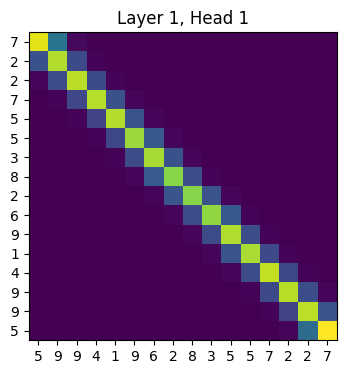

In [50]:
# Plot the attention maps for the first sequence in the batch
plot_attention_maps(data_input, attention_maps, idx=0)